In [9]:
%matplotlib inline

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

In [33]:
df = pd.read_csv('datasets/laptops_cleaned.csv')

In [6]:
df.head()

,Brand,processor_brand,processor_series,processor_tier,ram,storage,screen_size,display_type,gpu_brand,gpu_model,vram,prices
0,Lenovo,Intel,Core Ultra,7,32,1TB,16.0,WQXGA,Integrated,Integrated,0,214999
1,Dell,Intel,Core,7,16,1TB,16.0,WQXGA,Integrated,Integrated,0,159990
2,Acer,AMD,Ryzen,3,8,512GB,15.6,FHD,Integrated,Integrated,0,52599
3,Samsung,Intel,Core Ultra,7,16,512GB,16.0,WUXGA,Integrated,Integrated,0,131990
4,Samsung,Intel,Core Ultra,5,16,512GB,16.0,WUXGA,Integrated,Integrated,0,123990


## Univariate  Analysis

### Categorical columns

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 314 entries, 0 to 313
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             314 non-null    object 
 1   processor_brand   314 non-null    object 
 2   processor_series  314 non-null    object 
 3   processor_tier    314 non-null    int64  
 4   ram               314 non-null    int64  
 5   storage           314 non-null    object 
 6   screen_size       314 non-null    float64
 7   display_type      314 non-null    object 
 8   gpu_brand         314 non-null    object 
 9   gpu_model         314 non-null    object 
 10  vram              314 non-null    int64  
 11  prices            314 non-null    int64  
dtypes: float64(1), int64(4), object(7)
memory usage: 29.6+ KB


In [77]:
df['Brand'].isnull().sum()

np.int64(0)

In [78]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

In [79]:
# df['display_type'] = df['display_type'].str.replace('Full HD', 'FHD')
# df['display_type'] = df['display_type'].str.replace('2.5k', '2.5K')

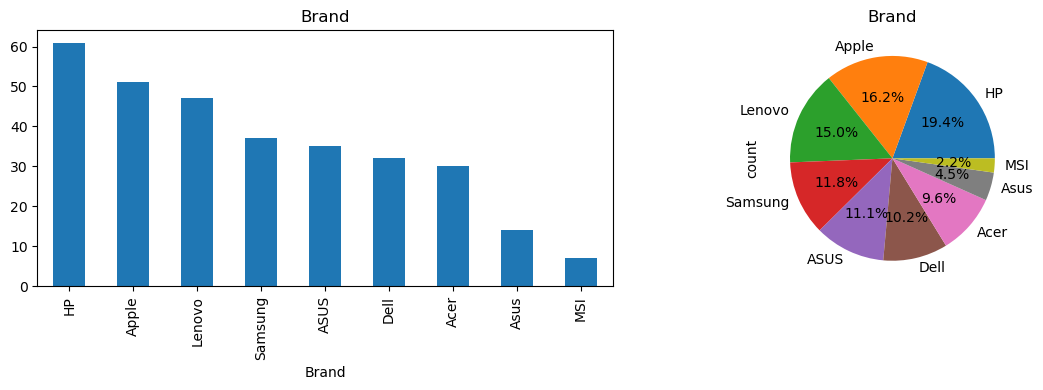

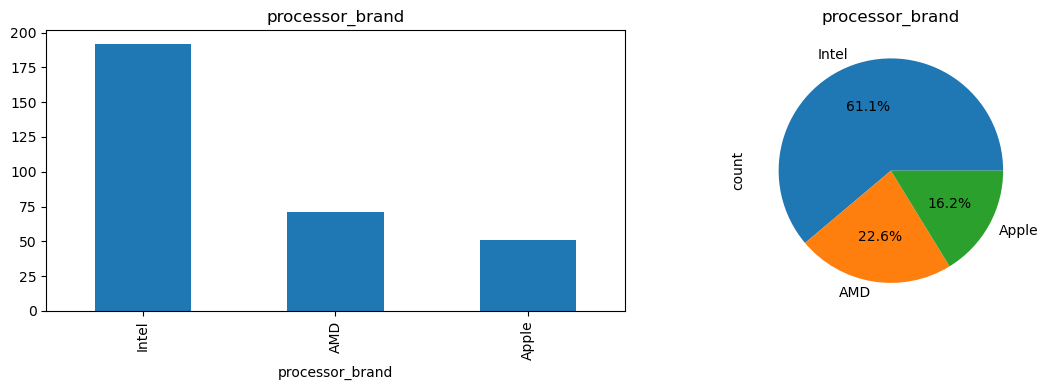

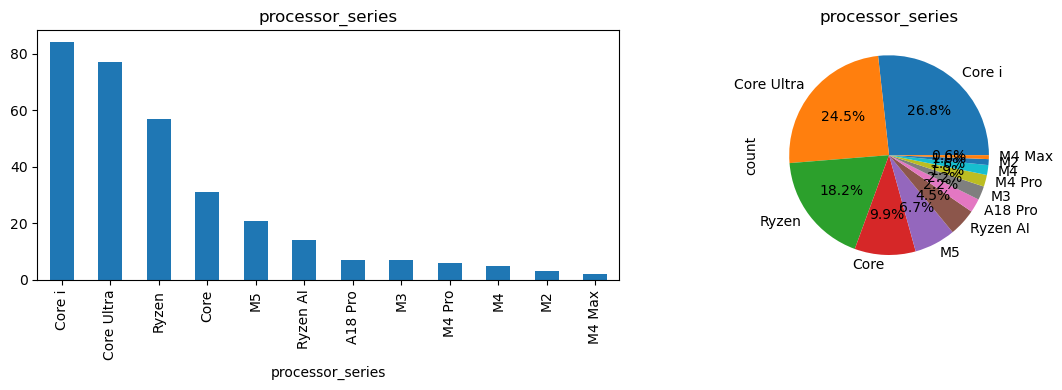

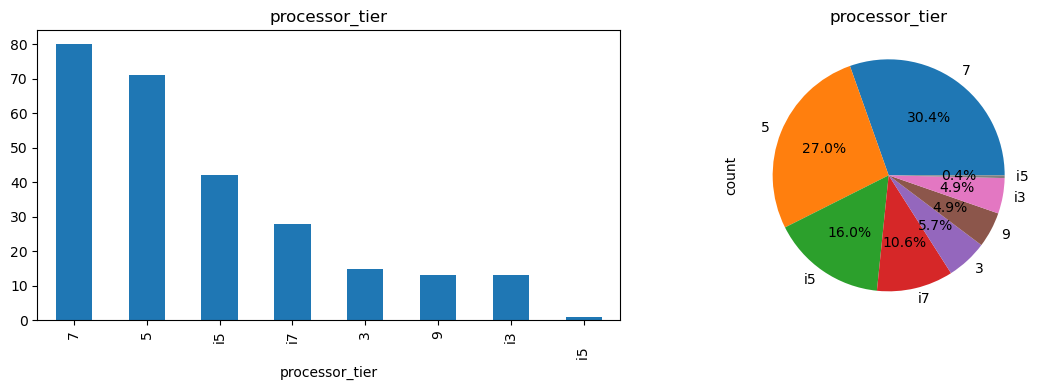

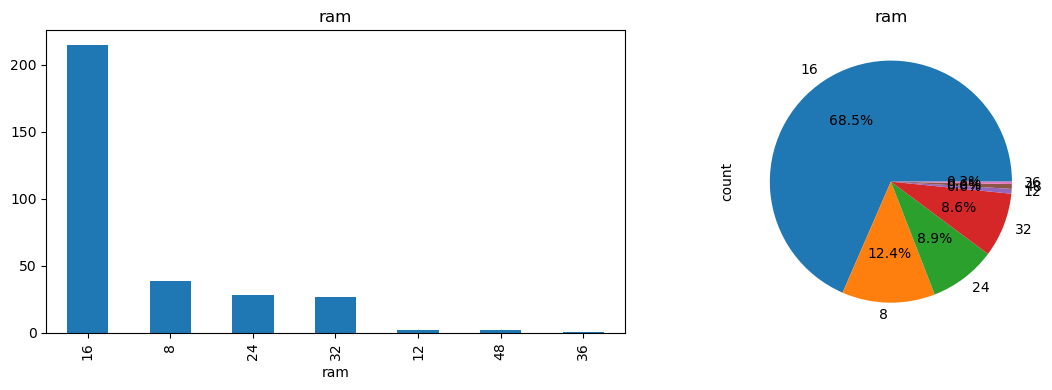

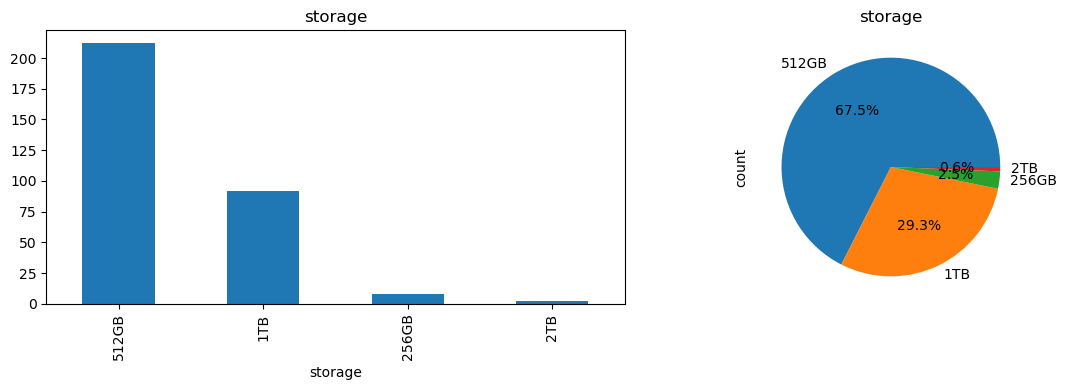

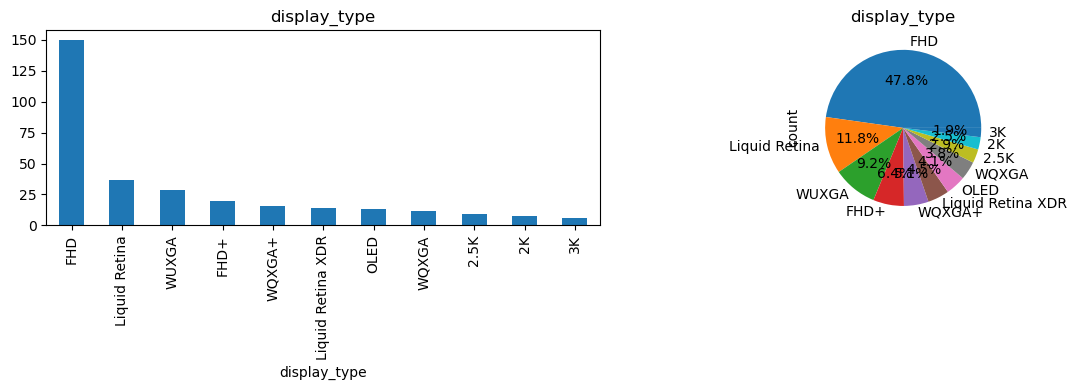

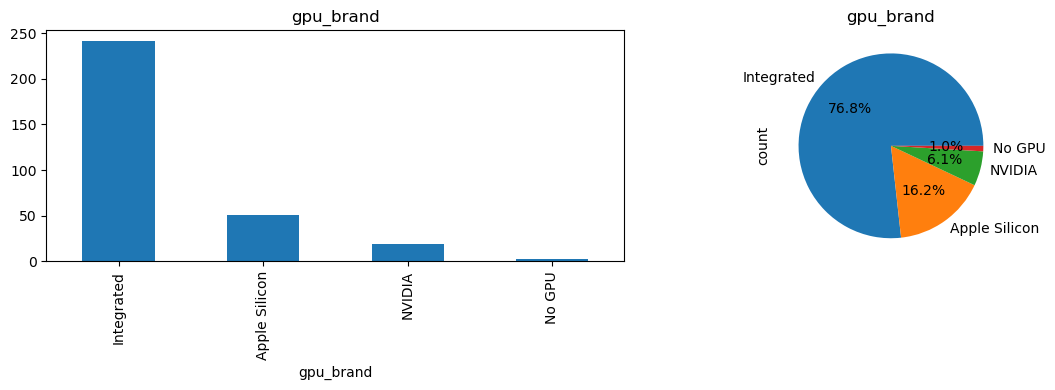

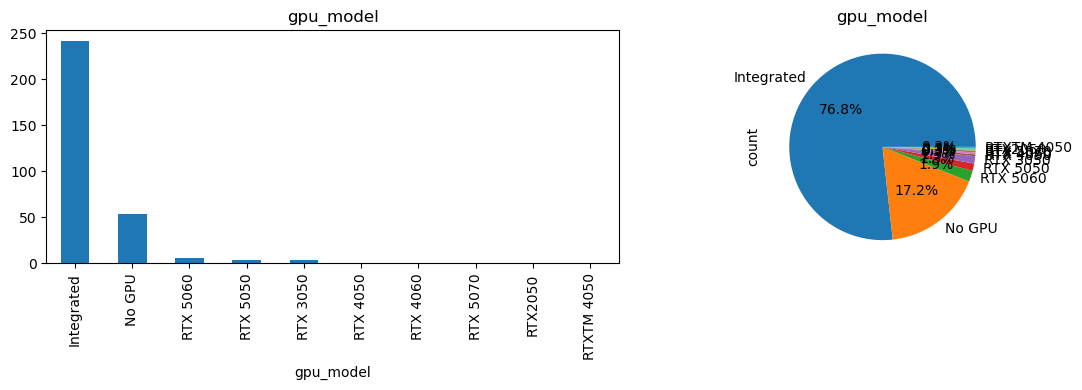

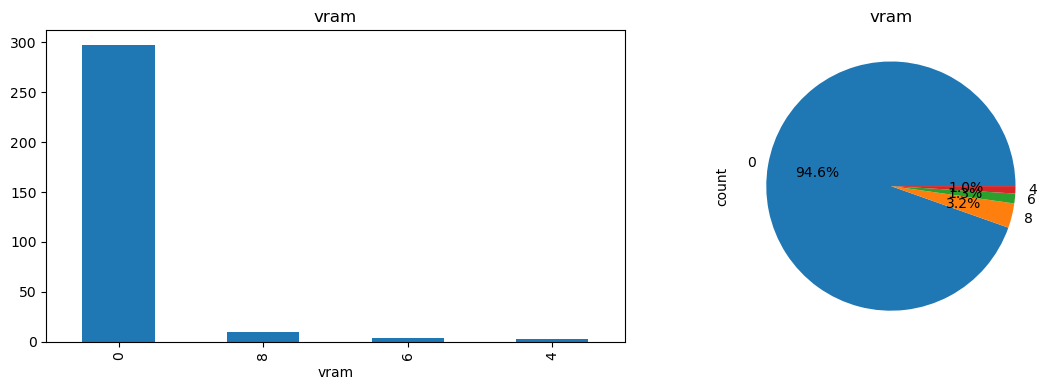

In [80]:
for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    df[col].value_counts().plot(kind='bar', ax=axes[0])
    df[col].value_counts().plot(kind='pie', autopct='%0.1f%%', ax=axes[1])
    axes[0].set_title(col)
    axes[1].set_title(col)
    plt.tight_layout()
    plt.show()

## Observations - 
* HP dominates the market with most number of laptops about 19.4 %
* Most of the laptops uses Intel processors (61.1%)
* Most laptops use 16GB RAM (majority share). 12GB is an uncommon tier, while 48GB and 36GB are rare as they appear mostly in premium/high-end laptops.
* Most of the laptops uses 512gb of storage (67.5%)
* Most of the laptops has FHD panels in them (47.8%)
* Most Laptops uses Integrated gpus (76.8%)

### Numeric Columns

In [51]:
num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols

['screen_size', 'prices']

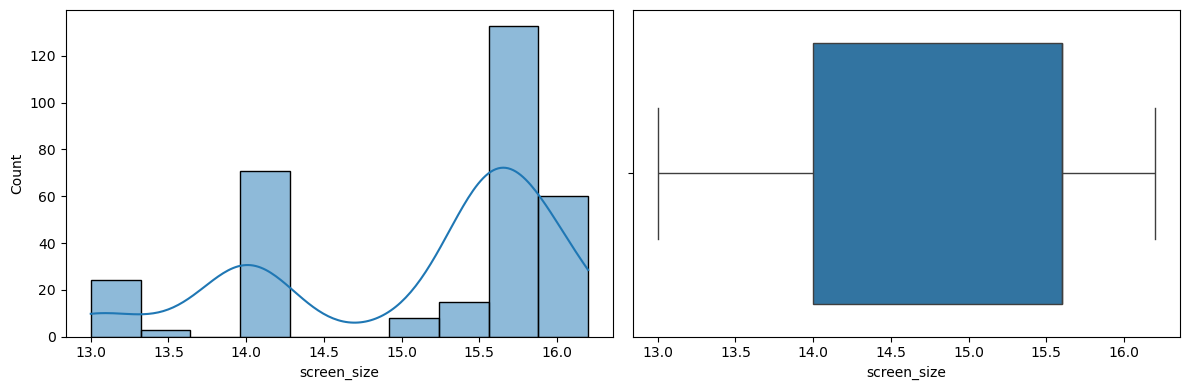

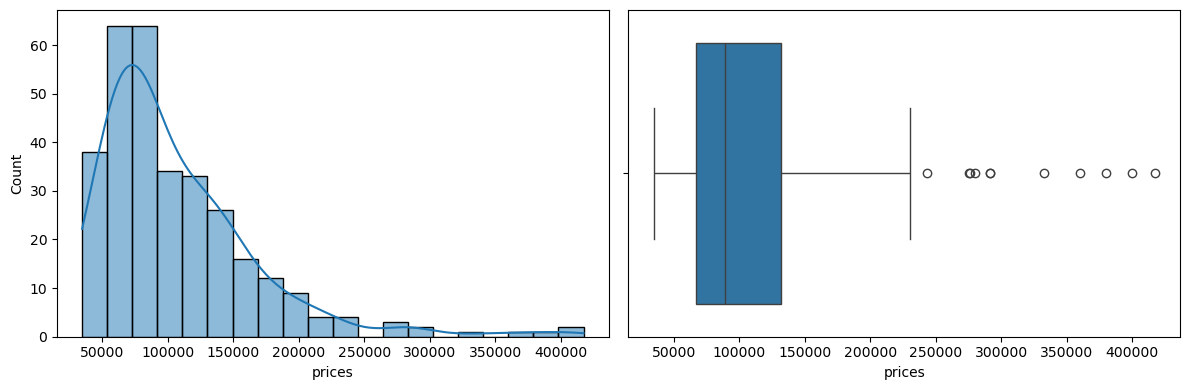

In [52]:
for num in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[num], kde=True, ax=axes[0])
    sns.boxplot(data=df, x=num, ax=axes[1])
    plt.tight_layout()
    plt.show()

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 314 entries, 0 to 313
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             314 non-null    object 
 1   processor_brand   314 non-null    object 
 2   processor_series  314 non-null    object 
 3   processor_tier    263 non-null    object 
 4   ram               314 non-null    object 
 5   storage           314 non-null    object 
 6   screen_size       314 non-null    float64
 7   display_type      314 non-null    object 
 8   gpu_brand         314 non-null    object 
 9   gpu_model         314 non-null    object 
 10  vram              314 non-null    object 
 11  prices            314 non-null    int64  
dtypes: float64(1), int64(1), object(10)
memory usage: 29.6+ KB


In [83]:
df['prices'].describe()

count       314.000000
mean     107010.334395
std       60622.250706
min       34499.000000
25%       66621.750000
50%       88994.500000
75%      131990.000000
max      417190.000000
Name: prices, dtype: float64

In [84]:
iqr = (131990 - 66621)
max_price = 131990 + 1.5*iqr
min_price = 66621 - 1.5*iqr
print(min_price, max_price)

-31432.5 230043.5


In [56]:
df[df['prices'] > max_price]

,Brand,processor_brand,processor_series,processor_tier,ram,storage,screen_size,display_type,gpu_brand,gpu_model,vram,prices
21,Samsung,Intel,Core Ultra,7,32,1TB,14.0,WQXGA+,Integrated,Integrated,0,291190
50,Samsung,Intel,Core Ultra,7,32,1TB,14.0,WQXGA+,Integrated,Integrated,0,291190
126,ASUS,Intel,Core Ultra,9,32,1TB,16.0,2.5k,NVIDIA,RTX 5070,8,275990
135,ASUS,Intel,Core Ultra,9,32,2TB,16.0,2.5K,Integrated,Integrated,0,399990
136,ASUS,Intel,Core Ultra,9,32,1TB,16.0,2.5K,Integrated,Integrated,0,279990
137,ASUS,Intel,Core Ultra,9,32,2TB,16.0,2.5K,Integrated,Integrated,0,359990
170,Samsung,Intel,Core Ultra,7,32,1TB,16.0,WQXGA+,Integrated,Integrated,0,242990
171,Samsung,Intel,Core Ultra,7,32,1TB,16.0,WQXGA+,Integrated,Integrated,0,417190
283,Apple,Apple,M4 Pro,NaN,48,512GB,16.2,Liquid Retina XDR,No GPU,No GPU,0,275399
286,Apple,Apple,M4 Max,NaN,36,1TB,16.2,Liquid Retina XDR,No GPU,No GPU,0,332500


## Observations
* Most of the laptops have 15.5 or 16 inches screen
* The prices are right skwed. Most of the laptops are under 1 lac
* There are some outliers but its mostly due to brand value or high end specs
* 50% of the laptops are under 88k 

## Bivariate analylsis

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 314 entries, 0 to 313
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             314 non-null    object 
 1   processor_brand   314 non-null    object 
 2   processor_series  314 non-null    object 
 3   processor_tier    263 non-null    object 
 4   ram               314 non-null    object 
 5   storage           314 non-null    object 
 6   screen_size       314 non-null    float64
 7   display_type      314 non-null    object 
 8   gpu_brand         314 non-null    object 
 9   gpu_model         314 non-null    object 
 10  vram              314 non-null    object 
 11  prices            314 non-null    int64  
dtypes: float64(1), int64(1), object(10)
memory usage: 29.6+ KB


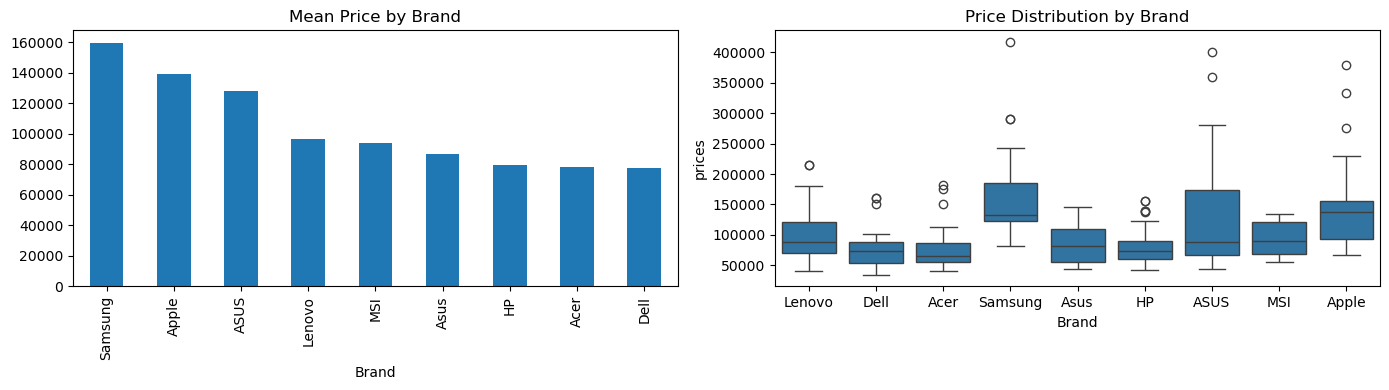

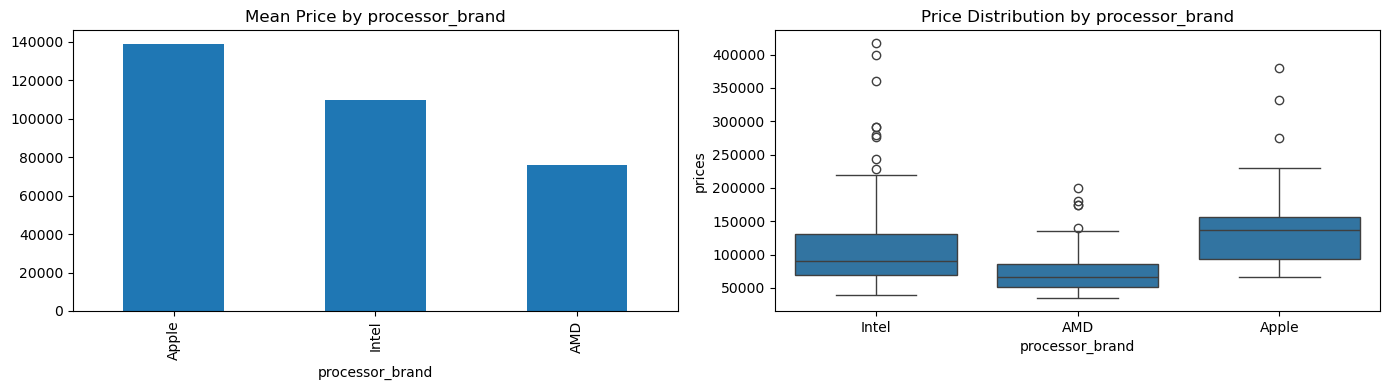

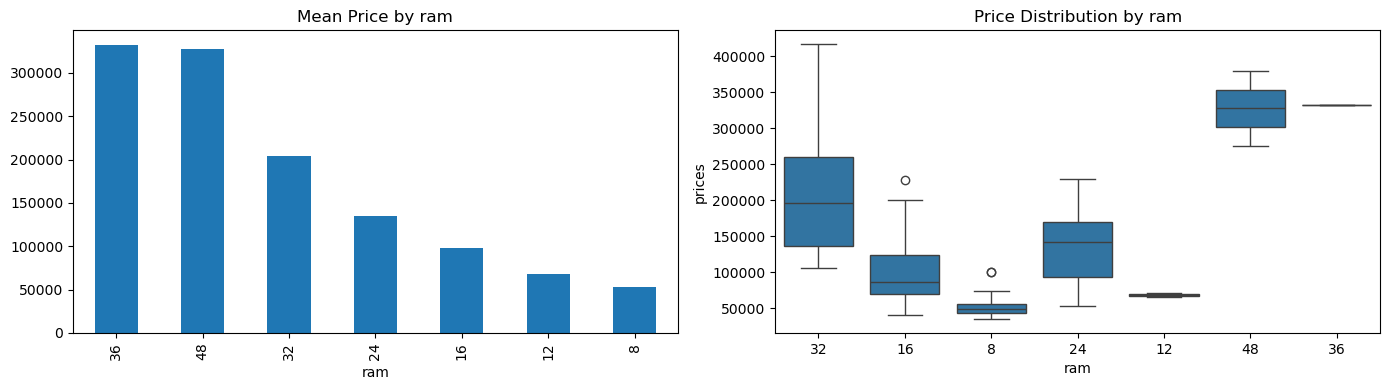

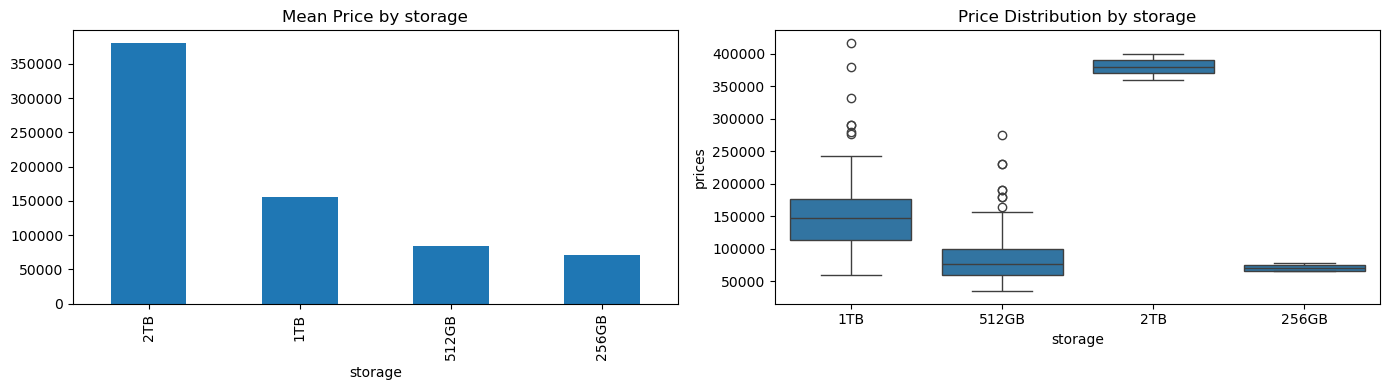

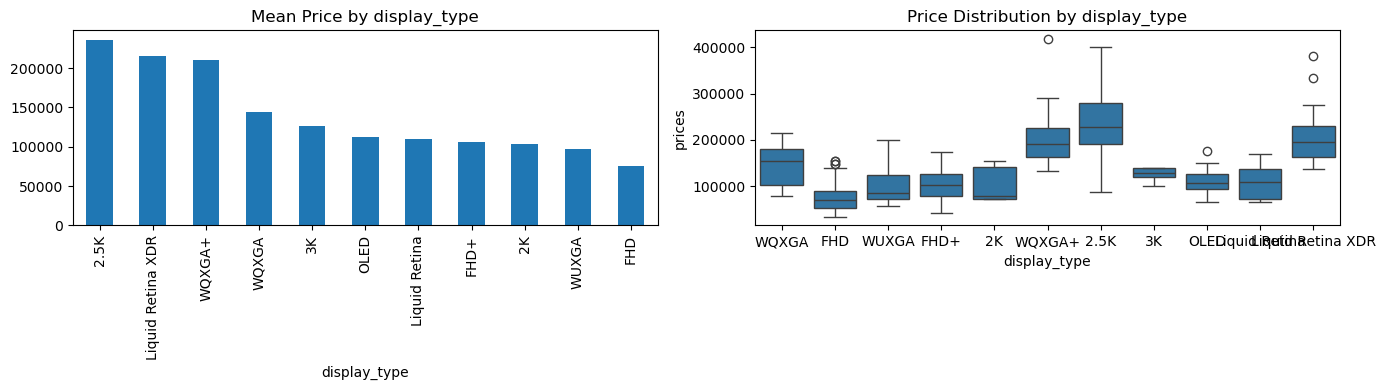

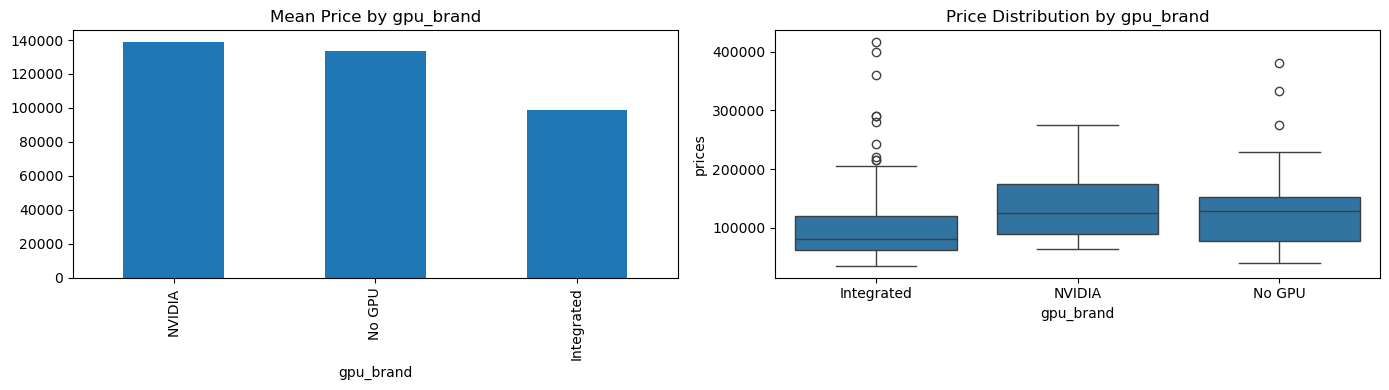

In [71]:
bi_cols = ['Brand', 'processor_brand', 'ram', 'storage', 'display_type', 'gpu_brand']
for col in bi_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    df.groupby(col)['prices'].mean().sort_values(ascending=False).plot(kind='bar', ax=axes[0])
    axes[0].set_title(f'Mean Price by {col}')
    sns.boxplot(data=df, x=col, y='prices', ax=axes[1])
    axes[1].set_title(f'Price Distribution by {col}')
    plt.tight_layout()
    plt.show()

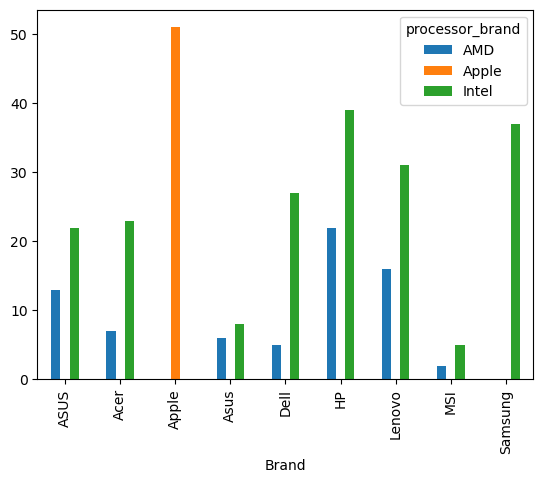

In [100]:
df.groupby(['Brand', 'processor_brand'])['processor_brand'].count().unstack().plot(kind='bar')
plt.show()

In [101]:
df.groupby(['Brand', 'processor_brand'])['processor_brand'].count()

Brand    processor_brand
ASUS     AMD                13
         Intel              22
Acer     AMD                 7
         Intel              23
Apple    Apple              51
Asus     AMD                 6
         Intel               8
Dell     AMD                 5
         Intel              27
HP       AMD                22
         Intel              39
Lenovo   AMD                16
         Intel              31
MSI      AMD                 2
         Intel               5
Samsung  Intel              37
Name: processor_brand, dtype: int64

In [103]:
df[(df['ram'] == '36') | (df['ram'] == '48')]

,Brand,processor_brand,processor_series,processor_tier,ram,storage,screen_size,display_type,gpu_brand,gpu_model,vram,prices
283,Apple,Apple,M4 Pro,NaN,48,512GB,16.2,Liquid Retina XDR,Apple Silicon,No GPU,0,275399
286,Apple,Apple,M4 Max,NaN,36,1TB,16.2,Liquid Retina XDR,Apple Silicon,No GPU,0,332500
290,Apple,Apple,M4 Max,NaN,48,1TB,16.2,Liquid Retina XDR,Apple Silicon,No GPU,0,379905


## Observations
* On avg Samsung's laptops the most expensive around 1.5 lacs
* Though Samsung's laptops are most expensive and they all uses intel processors but on avg laptops using apple processor are most expensive cause moslty all the laptops using apple processor are expensive while some intel laptops are expensive and some are very cheap
* Laptops with 48gb of ram should be on avg expensive than laptops with 36 gb of ram but that is not the case here cause of processor_series which is impacting the price
* laptops with 2TB of storage are on avg most expensive
* laptops with 2.5K panel is on avg most expensive
* laptops with nvidea gpus are on avg most expensive but there is not much diff between nvidea and no gpus laptops in this dataset

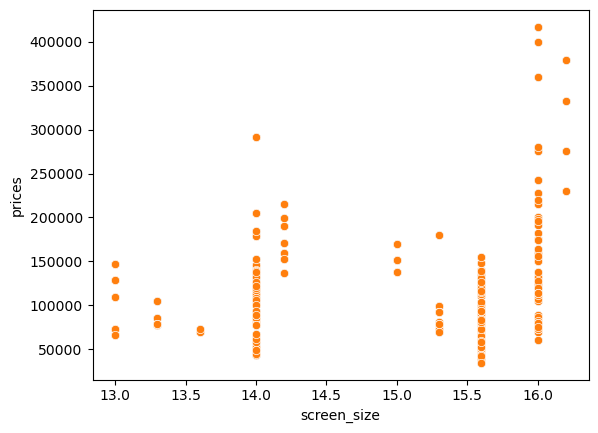

In [73]:
sns.scatterplot(data=df, x='screen_size', y='prices')
plt.show()

In [74]:
df.corr(numeric_only=True)

,screen_size,prices
screen_size,1.000000,0.068965
prices,0.068965,1.000000


## Observations - 
* There is not much correlations between prices and screensize some laptops with smaller screen are expensive then laptops with larger screen and vice versa

In [4]:
df[df['screen_size'] == 14]

,Brand,processor_brand,processor_series,processor_tier,ram,storage,screen_size,display_type,gpu_brand,gpu_model,vram,prices
6,Samsung,Intel,Core Ultra,7,16,512GB,14.0,WUXGA,Integrated,Integrated,0,124990
7,Samsung,Intel,Core Ultra,5,16,512GB,14.0,WUXGA,Integrated,Integrated,0,112990
13,Asus,Intel,Core Ultra,5,16,512GB,14.0,FHD+,Integrated,Integrated,0,81990
16,Asus,Intel,Core Ultra,9,32,1TB,14.0,FHD+,Integrated,Integrated,0,145990
18,Asus,AMD,Ryzen AI,5,16,512GB,14.0,FHD+,Integrated,Integrated,0,61990
...,...,...,...,...,...,...,...,...,...,...,...,...
255,HP,Intel,Core Ultra,7,16,512GB,14.0,3K,Integrated,Integrated,0,138999
275,Dell,Intel,Core i,i5,16,512GB,14.0,FHD,Integrated,Integrated,0,66999
310,HP,Intel,Core Ultra,7,32,1TB,14.0,3K,Integrated,Integrated,0,121999
311,ASUS,Intel,Core Ultra,9,32,1TB,14.0,OLED,Integrated,Integrated,0,137990


In [34]:
df = pd.read_csv('datasets/laptops_cleaned.csv', dtype={'processor_tier': str, 'ram': str, 'storage': str, 'vram': str})

In [19]:
sorted(df['Brand'].unique().tolist())

['ASUS', 'Acer', 'Apple', 'Asus', 'Dell', 'HP', 'Lenovo', 'MSI', 'Samsung']

In [20]:
df.groupby('processor_brand')['processor_series'].unique().apply(list).to_dict()

{'AMD': ['Ryzen', 'Ryzen AI'],
 'Apple': ['A18 Pro', 'M5', 'M2', 'M4 Pro', 'M4', 'M3', 'M4 Max'],
 'Intel': ['Core Ultra', 'Core', 'Core i']}

In [21]:
df.groupby('processor_brand')['processor_tier'].unique().apply(list).to_dict()

{'AMD': ['3', '7', '5', '9'], 'Apple': ['0'], 'Intel': ['7', '5', '3', '9']}

In [22]:
df.groupby('gpu_brand')['gpu_model'].unique().apply(list).to_dict()

{'Integrated': ['Integrated'],
 'NVIDIA': ['RTX 5050',
  'RTX 3050',
  'RTX 4050',
  'RTX 5060',
  'RTX 4060',
  'RTX 5070',
  'RTX2050',
  'RTXTM 4050'],
 'No GPU': ['No GPU']}

In [23]:
df.groupby('gpu_brand')['vram'].unique().apply(list).to_dict()

{'Integrated': ['0'], 'NVIDIA': ['0', '6', '8', '4'], 'No GPU': ['0']}

In [35]:
import plotly.express as px
import plotly.io as pio

In [36]:
coffee_colors = ['#6f4e37', '#a47148', '#c9a17a', '#e3d5c4', '#9c8170', '#4a3728']

template = dict(
    layout=dict(
        font=dict(family='-apple-system, Segoe UI, Roboto, sans-serif', color='#3e2f25'),
        plot_bgcolor='#f8f3ec',
        paper_bgcolor='#f8f3ec',
        title=dict(font=dict(size=16, color='#4a3728')),
        colorway=coffee_colors,
        xaxis=dict(gridcolor='#e3d5c4', linecolor='#e3d5c4'),
        yaxis=dict(gridcolor='#e3d5c4', linecolor='#e3d5c4'),
    )
)

pio.templates['coffee'] = template
pio.templates.default = 'coffee'

In [57]:
os.makedirs('flask app/static/plots', exist_ok=True)
# 1. Brand distribution - bar chart
fig1 = px.bar(df['Brand'].value_counts().reset_index(), x='Brand', y='count',
               title='Laptop Count by Brand')


# 2. GPU brand share - pie chart
fig2 = px.pie(df, names='gpu_brand', title='GPU Brand Share')
fig2.update_layout(
    height=350,
    margin=dict(t=60, b=60, l=20, r=20),
    legend=dict(orientation='h', yanchor='bottom', y=-0.3, xanchor='center', x=0.5)
)
# 3. Price distribution - histogram
fig3 = px.histogram(df, x='prices', nbins=30, title='Price Distribution')


# 4. Avg price by brand - bar chart
avg_price = df.groupby('Brand')['prices'].mean().sort_values(ascending=False).reset_index()
fig4 = px.bar(avg_price, x='Brand', y='prices', title='Average Price by Brand')


# 5. Avg price by gpu_brand - bar chart
avg_price_gpu = df.groupby('gpu_brand')['prices'].mean().sort_values(ascending=False).reset_index()
fig5 = px.bar(avg_price_gpu, x='gpu_brand', y='prices', title='Average Price by GPU Brand')


# 6. Price by RAM - boxplot
df['ram'] = df['ram'].astype(str)

ram_order = ['8', '12', '16', '24', '32', '36', '48']
fig6 = px.box(df, x='ram', y='prices', title='Price Distribution by RAM',
              category_orders={'ram': ram_order})
fig6.update_xaxes(type='category', categoryorder='array', categoryarray=ram_order)


fig1.write_html('flask app/static/plots/brand_dist.html')
fig2.write_html('flask app/static/plots/gpu_share.html')
fig3.write_html('flask app/static/plots/price_dist.html')
fig4.write_html('flask app/static/plots/avg_price_brand.html')
fig5.write_html('flask app/static/plots/avg_price_gpu.html')
fig6.write_html('flask app/static/plots/price_ram_box.html')

In [40]:
import os
print(os.getcwd())

os.makedirs(r'C:\Users\Himanshu\OneDrive\Documents\my documents\python course\Python_Projects\Laptop-Price-Predictor\flask app\static\plots', exist_ok=True)

C:\Users\Himanshu\OneDrive\Documents\my documents\python course\Python_Projects\Laptop-Price-Predictor


In [43]:
os.makedirs('flask app/static/plots', exist_ok=True)
print(os.getcwd())

C:\Users\Himanshu\OneDrive\Documents\my documents\python course\Python_Projects\Laptop-Price-Predictor


In [49]:
df['ram'].unique()

array(['32', '16', '8', '24', '12', '48', '36'], dtype=object)

In [52]:
print(fig6.layout.xaxis.type)

category
